# Psychometric and chronometric curves

In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Get my functions

from one.api import ONE
one = ONE(mode='remote')

In [3]:
data_path = prefix + 'representation_learning_variability/paper-individuality/1_segmentation/'
trials_file = pd.read_parquet(data_path+'all_trials_26-03-2026')

In [11]:
trials_file.loc[trials_file['choice']=='right', 'choice'] = 1
trials_file.loc[trials_file['choice']=='left', 'choice'] = 0
trials_file.loc[trials_file['block']=='0.2', 'block'] = 0.2
trials_file.loc[trials_file['block']=='0.5', 'block'] = 0.5
trials_file.loc[trials_file['block']=='0.8', 'block'] = 0.8

trials_file['signed_contrast'] = trials_file['contrast']
trials_file.loc[(trials_file['correct']==0) & 
                (trials_file['choice']==1), 'signed_contrast'] = - trials_file['signed_contrast']
trials_file.loc[(trials_file['correct']==1) & 
                (trials_file['choice']==0), 'signed_contrast'] = - trials_file['signed_contrast']
trials_file['signed_contrast'] = trials_file['signed_contrast']*100


In [32]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
cluster_df = pd.read_parquet(data_path+'18_trial_waterclust')

In [33]:
cluster_df['trial_id'] = cluster_df['sample'].str.split().str[1:2].str.join('')
cluster_df['trial_id'] = cluster_df['trial_id'].astype(float)

In [34]:
psych_df = trials_file.merge(cluster_df[['trial_id', 'session', 'trial_cluster']], on=['trial_id', 'session'])

In [35]:
psych_df['movement'] = psych_df['response'] - psych_df['reaction']

# Psychometric curves

IndexError: index 18 is out of bounds for axis 0 with size 18

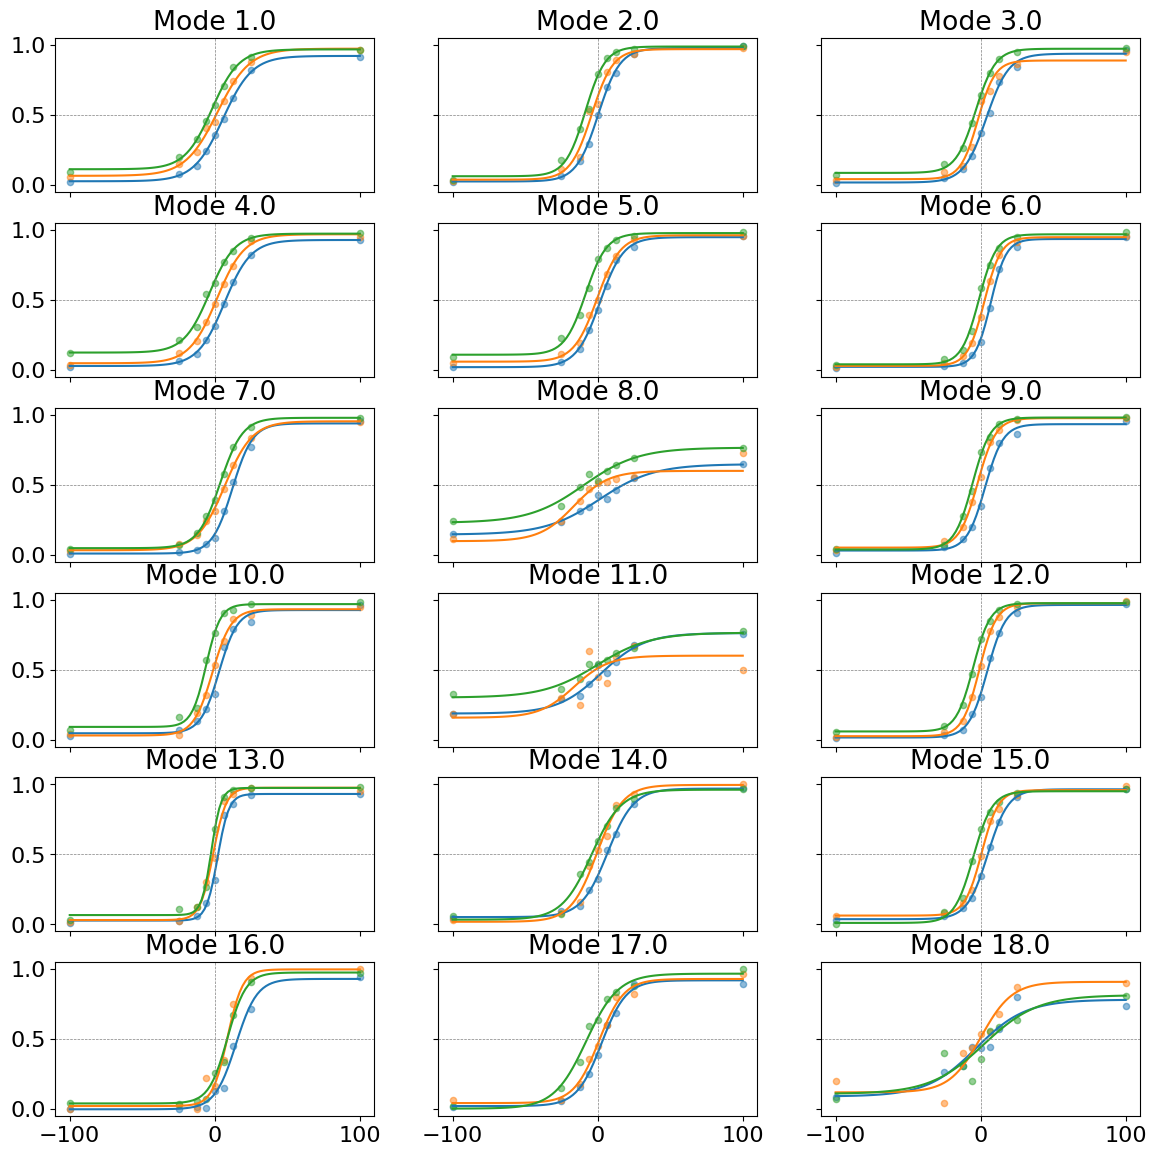

In [41]:

# 1. Define the Psychometric Function (Logistic)
def sigmoid(x, mu, sigma, gamma, lambda_):
    """
    Standard psychometric function:
    mu: threshold (bias)
    sigma: slope (sensitivity)
    gamma: lapse rate (lower)
    lambda_: lapse rate (upper)
    """
    return gamma + (1 - gamma - lambda_) * (1 / (1 + np.exp(-(x - mu) / sigma)))


# 3. Plotting logic
modes = sorted(psych_df['trial_cluster'].unique())
fig, axes = plt.subplots(6, 3, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()

colors = {0.2: 'tab:blue', 0.5: 'tab:orange', 0.8: 'tab:green'}

for i, mode in enumerate(modes):
    ax = axes[i]
    mode_data = psych_df[psych_df['trial_cluster'] == mode]
    
    for block in sorted(mode_data['block'].unique()):
        block_data = mode_data[mode_data['block'] == block]
        
        # Calculate empirical means for the scatter plot
        summary = block_data.groupby('signed_contrast')['choice'].mean().reset_index()
        
        # Plot empirical points
        ax.scatter(summary['signed_contrast'], summary['choice'], 
                   color=colors[block], alpha=0.5, s=20)
        
        # Fit the sigmoid
        try:
            # p0 initial guess: [bias=0, slope=10, lapse_L=0.05, lapse_R=0.05]
            popt, _ = curve_fit(sigmoid, block_data['signed_contrast'], block_data['choice'], 
                                p0=[0, 10, 0.05, 0.05], 
                                bounds=([-100, 0.1, 0, 0], [100, 100, 0.4, 0.4]))
            
            x_range = np.linspace(-100, 100, 100)
            ax.plot(x_range, sigmoid(x_range, *popt), color=colors[block], label=f'Block {block}')
        except Exception as e:
            # If a fit fails, the plot just shows the scatter points
            pass
            
    ax.set_title(f'Mode {mode}')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Chronometric curves

In [48]:
psych_df['log_reaction'] = np.log(psych_df['reaction'])

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


IndexError: index 18 is out of bounds for axis 0 with size 18

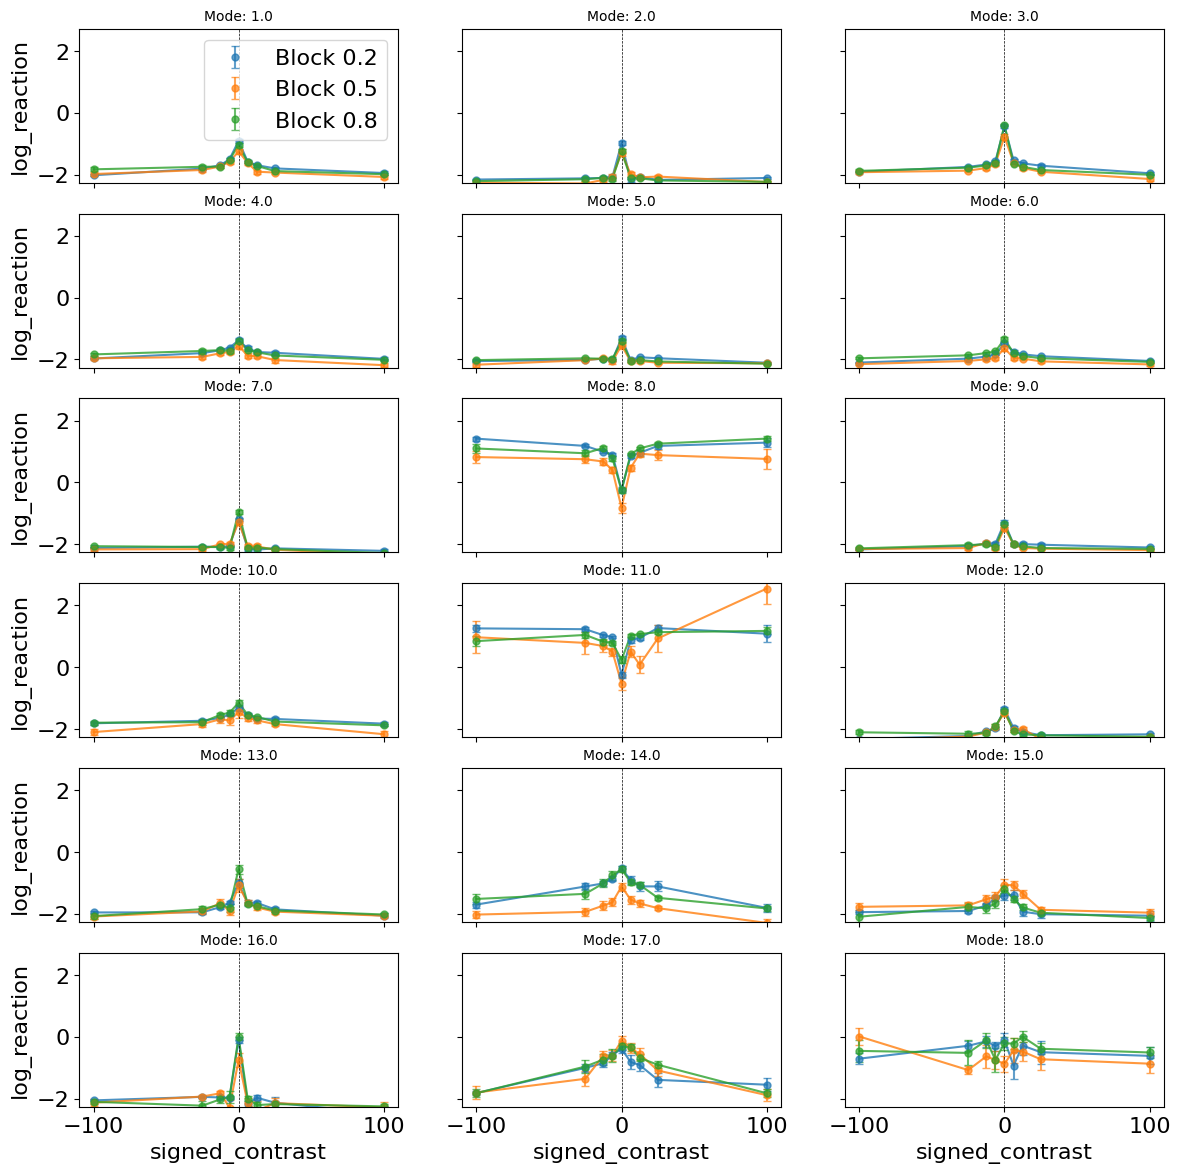

In [49]:
# 1. Plotting Setup
use_metric = 'log_reaction'
modes = sorted(psych_df['trial_cluster'].unique())
# fig, axes = plt.subplots(6, 3, figsize=(16, 22), sharex=True, sharey=True) # y-scales might vary by mode
fig, axes = plt.subplots(6, 3, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()

colors = {0.2: 'tab:blue', 0.5: 'tab:orange', 0.8: 'tab:green'}

for i, mode in enumerate(modes):
    ax = axes[i]
    mode_data = psych_df[psych_df['trial_cluster'] == mode]
    
    for block in sorted(mode_data['block'].unique()):
        block_data = mode_data[mode_data['block'] == block]
        
        if block_data.empty: continue
        # --- Empirical Calculation ---
        # We calculate the mean RT for each signed contrast level
        # Also calculating SEM (Standard Error of Mean) for the error bars
        summary = block_data.groupby('signed_contrast')[use_metric].agg(['mean', 'sem']).reset_index()
        
        # Plotting the points and error bars
        ax.errorbar(summary['signed_contrast'], summary['mean'], yerr=summary['sem'],
                    fmt='o', color=colors[block], markersize=5, capsize=3, 
                    alpha=0.7, label=f'Block {block}' if i == 0 else "")
        
        # --- Smoothing / "Fitting" ---
        # Since RTs don't follow a simple sigmoid, we usually use a 
        # Lowess smoother or a simple line to show the trend.
        sns.lineplot(data=block_data, x='signed_contrast', y=use_metric, 
                     color=colors[block], ax=ax, errorbar=None, alpha=0.8)

    # Formatting
    ax.set_title(f'Mode: {mode}', fontsize=10)
    ax.axvline(0, color='black', lw=0.5, ls='--')
    ax.set_yscale('linear')  # Make y-axis logarithmic
    
    # Adjusting Y-axis to focus on the data range
    if not mode_data[use_metric].empty:
        y_min = mode_data[use_metric].quantile(0.05)
        y_max = mode_data[use_metric].quantile(0.95)
        ax.set_ylim(y_min * 0.8, y_max * 1.2)

# Figure labels
fig.text(0.5, 0.01, 'Signed Contrast (%)', ha='center', fontsize=14)
fig.text(0.01, 0.5, 'Mean Reaction Time (s)', va='center', rotation='vertical', fontsize=14)
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.98))

plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.98])
plt.show()

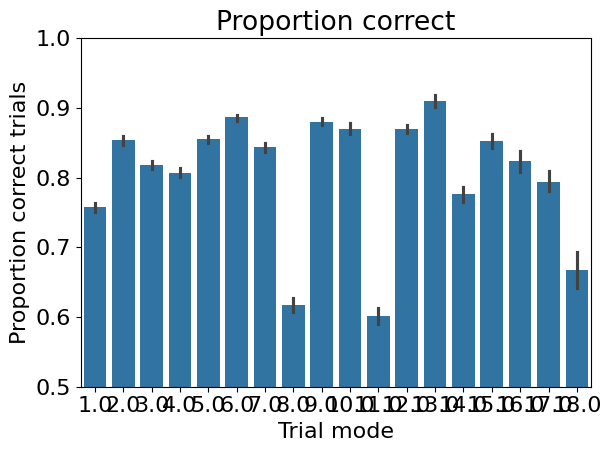

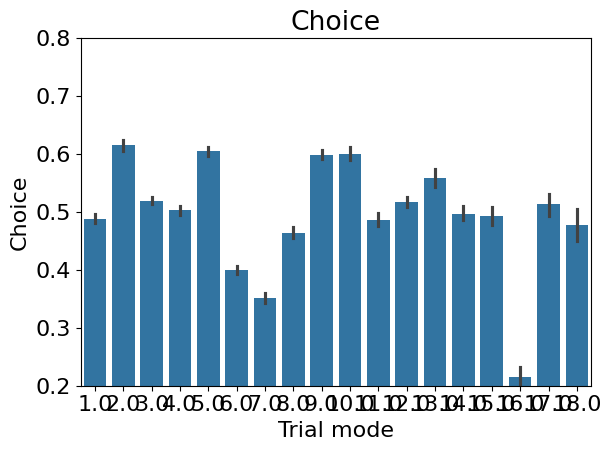

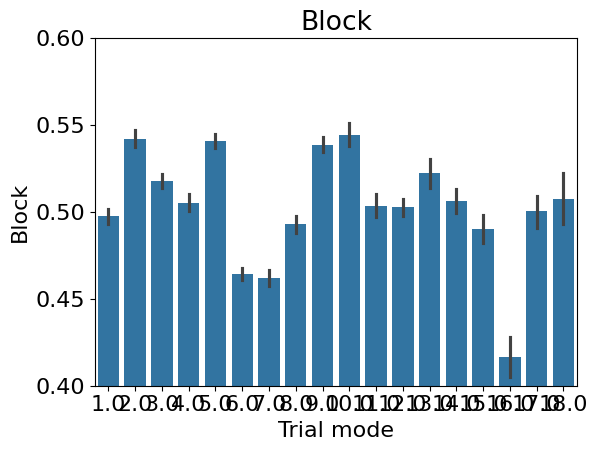

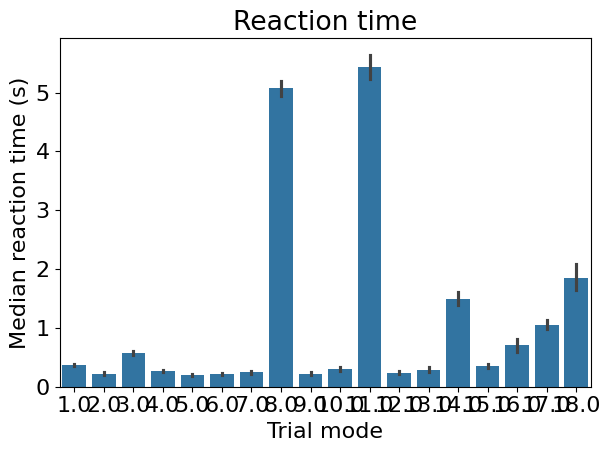

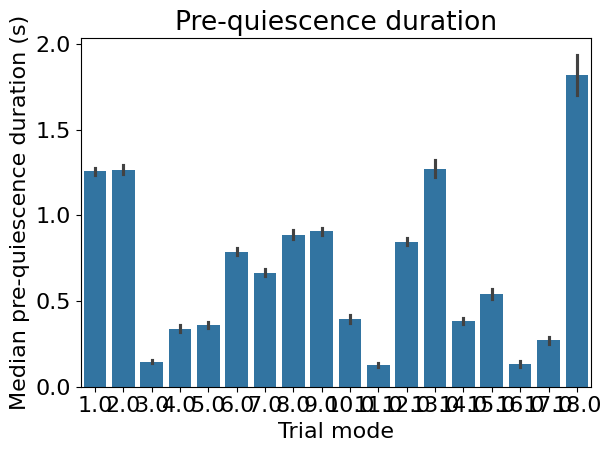

In [40]:
# save_path = prefix + 'representation_learning_variability/Exported figures/COSYNE/'
plt.rcParams.update({'font.size': 16})

sns.barplot(x='trial_cluster', y='correct', data=psych_df) #, palette='Set1')
plt.title('Proportion correct')
plt.ylabel('Proportion correct trials')
plt.ylim([0.5,1])
plt.xlabel('Trial mode')
plt.tight_layout()
plt.show()

sns.barplot(x='trial_cluster', y='choice', data=psych_df) #, palette=color_dict)
plt.ylabel('Choice')
plt.title('Choice')
plt.ylim([0.2,.8])
plt.tight_layout()
plt.xlabel('Trial mode')
plt.show()

sns.barplot(x='trial_cluster', y='block', data=psych_df) #, palette=color_dict)
plt.ylabel('Block')
plt.title('Block')
plt.ylim([0.4,.6])
plt.tight_layout()
plt.xlabel('Trial mode')
plt.show()


sns.barplot(x='trial_cluster', y='reaction', data=psych_df) #, palette=color_dict)
plt.ylabel('Median reaction time (s)')
plt.title('Reaction time')
plt.xlabel('Trial mode')
plt.tight_layout()
plt.show()

sns.barplot(x='trial_cluster', y='elongation', data=psych_df) #, palette=color_dict)
plt.ylabel('Median pre-quiescence duration (s)')
plt.title('Pre-quiescence duration')
plt.xlabel('Trial mode')
plt.tight_layout()
plt.show()


In [ ]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/fig1_segmentation/'
# merged_df.to_parquet(data_path+'trial_clusters_5', compression='gzip')